# Lecture 02: Review
- Data description
- Distribtions
- Probabilities

Acknowledgement: thanks Prof. Michael Tippett from APAM provide ENSO example

In [1]:
### Load modules/functions ###
import os
import numpy as np
import xarray as xr

from matplotlib import pyplot as plt
from scipy import stats
import matplotlib.patches as mpatches

from IPython.display import Image
from matplotlib import image


%config InlineBackend.figure_format = 'retina'
%matplotlib inline

We are are going to use NOAA ERSSTv5

- Extended Reconstructed Sea Surface Temperature Version 5

- Monthly data going back to January 1854
https://psl.noaa.gov/data/gridded/data.noaa.ersst.v5.html

In [2]:
# where you want the SST data file to go
dest = './ERSSTv5.sst.mnmean.nc'
url  = 'https://downloads.psl.noaa.gov/Datasets/noaa.ersst.v5/sst.mnmean.nc'

# large data, so we check if it has been downloaded
if os.path.exists(dest):
    !curl -L -R -z "{dest}" -o "{dest}" --fail "{url}"  ## only download if the remote file is newer...
else:
    !curl -L -R -o "{dest}" --fail "{url}" 

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0


## Describing the data

Let's look at data

In [3]:
dest = './ERSSTv5.sst.mnmean.nc'
ds_ersstv5 = xr.open_dataset(dest)
### Check data 
ds_ersstv5

/home/clee/anaconda3/envs/py3.9/lib/python3.9/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'cfgrib' loading failed:
libffi.so.7: cannot open shared object file: No such file or directory
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


<xarray.Dataset>
Dimensions:    (lat: 89, lon: 180, time: 2072, nbnds: 2)
Coordinates:
  * lat        (lat) float32 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon        (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1854-01-01 1854-02-01 ... 2026-08-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 ...
    sst        (time, lat, lon) float32 ...
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    creator_url_original:      https://www.ncei.noaa.gov
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2026-09-03

In [4]:
## Name the variables using conventional name
ds_ersstv5 = ds_ersstv5.rename({'lat': 'latitude', 'lon': 'longitude'})
ds_ersstv5.attrs['short_name'] = 'ERSSTv5'
ds_ersstv5

<xarray.Dataset>
Dimensions:    (latitude: 89, longitude: 180, time: 2072, nbnds: 2)
Coordinates:
  * latitude   (latitude) float32 88.0 86.0 84.0 82.0 ... -84.0 -86.0 -88.0
  * longitude  (longitude) float32 0.0 2.0 4.0 6.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1854-01-01 1854-02-01 ... 2026-08-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 ...
    sst        (time, latitude, longitude) float32 ...
Attributes: (12/38)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2026-09-03
    short_name:                ERSSTv5

Plot data and save images

In [5]:
### 2D map of SST for July 


- how warm it is?
- look at anomaly

- waht do you see

- is this a really strong ENSO?  comparable to 1997/8 ones?

- ENSO is defined using Nino3.4 box 5N-5S, 170W-120W  (i.e., 190E-240E)
### Function
- we can write a function to do it

In [6]:
def n34_average(x):
    """
    Calculate x (temperature) over Niño 3.4 region"
    Note that grid cells near the equator represent more actual surface area than cells near the poles 
    (since longitude lines converge toward the poles), 
    so a simple unweighted mean would bias the average toward high latitudes. Weighting by cos(latitude) corrects for this.
    """
    
    x = x.sortby("latitude")
    weights = np.cos(np.deg2rad(x.latitude))
    y = x.sel(longitude=slice(190, 240)).sel(latitude=slice(-5, 5)).weighted(weights).mean(['longitude', 'latitude'])
    y.attrs = x.attrs.copy()
    return y

- n34 data

### Histogram

### Sample Mean
$$\hat{\mu} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

### Sample Standard Deviation

$$\hat{\sigma} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (x_i - \hat{\mu})^2}$$

### Sample Skewness
$$\hat{\gamma} = \frac{\frac{1}{n}\sum_{i=1}^{n} (x_i - \hat{\mu})^3}{\hat{\sigma}^3}$$

### Sample Kurtosis
$$\hat{k} = \frac{\frac{1}{n}\sum_{i=1}^{n} (x_i - \hat{\mu})^4}{\hat{\sigma}^4}$$

### Quantiles

-- back to lecture--

Let's calculate n34 anomaly, and give me the all 5 moments and quantile of 5th and 95th value. Also, see where the anomalous n34 for July locats

### Distribution

### Normal Distribuiton
$$p(x) = \frac{1}{\hat{\sigma}\sqrt{2\pi}} \exp\left(-\frac{(x-\hat{\mu})^2}{2\hat{\sigma}^2}\right)$$

In [75]:
import pandas as pd

# Load data
df = pd.read_csv('n34_all.csv')
x = df['nino34'].dropna().values

# Fit normal distribution (returns MLE estimates of mu and sigma)
mu, sigma = stats.norm.fit(x)
print(f"n = {len(x)}")
print(f"mu (mean) = {mu:.4f}")
print(f"sigma (std) = {sigma:.4f}")

n = 2072
mu (mean) = 26.6582
sigma (std) = 1.0141


In [76]:
df

,time,nino34
0,1854-01-01,25.897331
1,1854-02-01,26.055464
2,1854-03-01,26.908459
3,1854-04-01,27.631338
4,1854-05-01,27.902256
...,...,...
2067,2026-04-01,28.126972
2068,2026-05-01,28.838810
2069,2026-06-01,29.267714
2070,2026-07-01,29.277988


Now let's use stats function to fit the data

In [77]:

xs = np.linspace(x.min(), x.max(), 200)
fit_x =stats.norm.pdf(xs, mu, sigma)


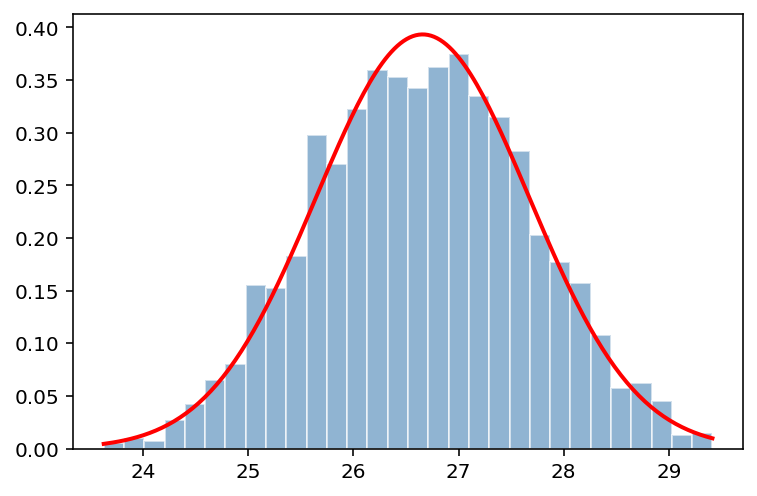

In [78]:
plt.hist(x, bins=30, density=True, alpha=0.6, color='steelblue', edgecolor='white')
plt.plot(xs, fit_x, 'r-', lw=2,
        label=f'Normal fit\n$\\mu$={mu:.2f}, $\\sigma$={sigma:.2f}')
plt.show()

- Q-Q plot:
stats.probplot https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.probplot.html

Text(0.5, 1.0, 'Q-Q Plot vs Normal Distribution')

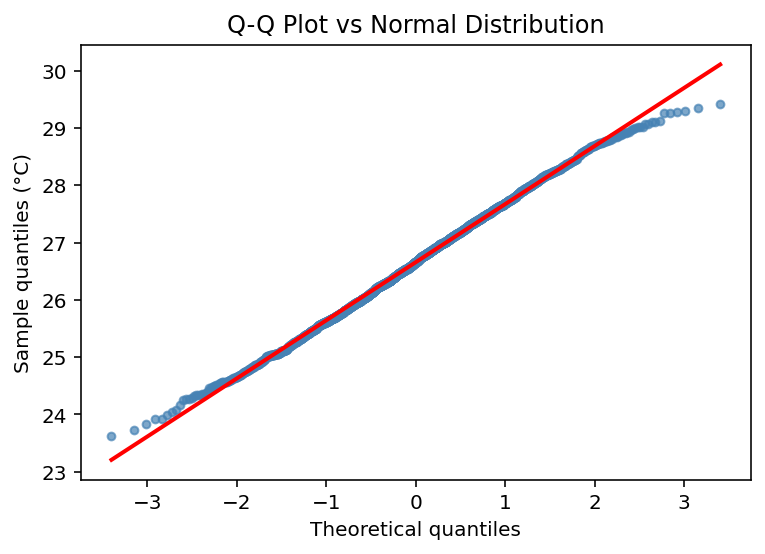

In [79]:
(osm, osr), (slope, intercept, r) = stats.probplot(x, dist='norm', plot=None)
plt.scatter(osm, osr, s=15, color='steelblue', alpha=0.7, label='Data')
plt.plot(osm, slope * osm + intercept, 'r-', lw=2, label=f'Fit line ($r^2$={r**2:.3f})')
plt.xlabel('Theoretical quantiles')
plt.ylabel('Sample quantiles (°C)')
plt.title('Q-Q Plot vs Normal Distribution')

### Gamma
$$p(x) = \frac{1}{\Gamma(k)\,\theta^{k}} x^{k-1} e^{-x/\theta}, \quad x > 0$$

In [81]:
df = pd.read_csv('NYC_data.csv')
df

,STATION,NAME,DATE,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,WT01,WT02,WT03,WT04,WT06,WT08,WT09
0,USW00094728,"NY CITY CENTRAL PARK, NY US",1999-01-01,0.00,0.0,NaN,20.0,28,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,USW00094728,"NY CITY CENTRAL PARK, NY US",1999-01-02,0.00,0.0,NaN,17.0,25,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,USW00094728,"NY CITY CENTRAL PARK, NY US",1999-01-03,2.42,0.0,NaN,38.0,51,24,1.0,NaN,NaN,NaN,NaN,1.0,NaN
3,USW00094728,"NY CITY CENTRAL PARK, NY US",1999-01-04,0.00,0.0,NaN,26.0,32,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,USW00094728,"NY CITY CENTRAL PARK, NY US",1999-01-05,0.00,0.0,NaN,23.0,28,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10073,USW00094728,"NY CITY CENTRAL PARK, NY US",2026-07-31,0.03,0.0,0.0,NaN,85,67,1.0,NaN,NaN,NaN,NaN,NaN,NaN
10074,USW00094728,"NY CITY CENTRAL PARK, NY US",2026-08-01,0.00,0.0,0.0,NaN,86,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10075,USW00094728,"NY CITY CENTRAL PARK, NY US",2026-08-02,0.07,0.0,0.0,NaN,83,75,1.0,NaN,NaN,NaN,NaN,NaN,NaN
10076,USW00094728,"NY CITY CENTRAL PARK, NY US",2026-08-03,1.93,0.0,0.0,NaN,80,71,1.0,NaN,1.0,NaN,NaN,NaN,NaN


<Axes: >

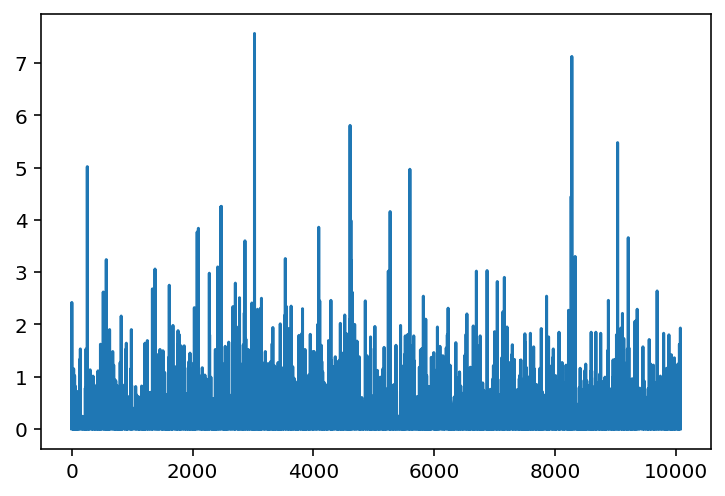

In [82]:
df.PRCP.plot()

- let's clean the data

In [84]:
df['DATE'] = pd.to_datetime(df['DATE'])
df['PRCP'] = pd.to_numeric(df['PRCP'], errors='coerce')
df = df.dropna(subset=['PRCP'])

# --- Isolate wet days (gamma is undefined at 0, and dry days dominate) ---
wet = df.loc[df['PRCP'] > 0, 'PRCP'].values
frac_wet = len(wet) / len(df)
print(f"Wet days: {len(wet)} ({frac_wet*100:.1f}% of days)")

Wet days: 3481 (34.5% of days)


In [87]:
wet

array([2.42, 0.39, 0.56, ..., 0.03, 0.07, 1.93])

In [ ]:
- fit and plot Gamma
\distribution

In [85]:
# --- Fit Gamma distribution (location fixed at 0, standard for precip) ---
shape, loc, scale = stats.gamma.fit(wet, floc=0)
print(f"Gamma fit: shape (k) = {shape:.4f}, scale (theta) = {scale:.4f}")
print(f"Implied mean = {shape*scale:.4f}, variance = {shape*scale**2:.4f}")


Gamma fit: shape (k) = 0.6491, scale (theta) = 0.6160
Implied mean = 0.3998, variance = 0.2463


Text(0.5, 1.0, 'Wet-day Precipitation with fitted Gamma\n(bin width = 0.1 in, n=3481)')

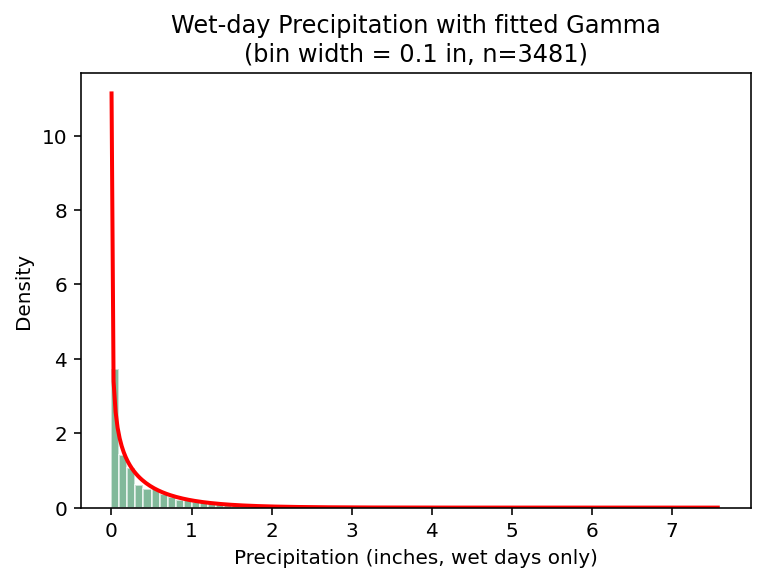

In [86]:
bin_width = 0.1
bins = np.arange(0, wet.max() + bin_width, bin_width)
plt.hist(wet, bins=bins, density=True, alpha=0.6, color='seagreen', edgecolor='white')
xs = np.linspace(0.001, wet.max(), 300)
fit_pdf = stats.gamma.pdf(xs, shape, loc, scale)
plt.plot(xs, fit_pdf, 'r-', lw=2,
        label=f'Gamma fit\nk={shape:.2f}, $\\theta$={scale:.2f}')
plt.xlabel('Precipitation (inches, wet days only)')
plt.ylabel('Density')
plt.title(f'Wet-day Precipitation with fitted Gamma\n(bin width = 0.1 in, n={len(wet)})')

Text(0.5, 1.0, 'Q-Q Plot vs Gamma Distribution')

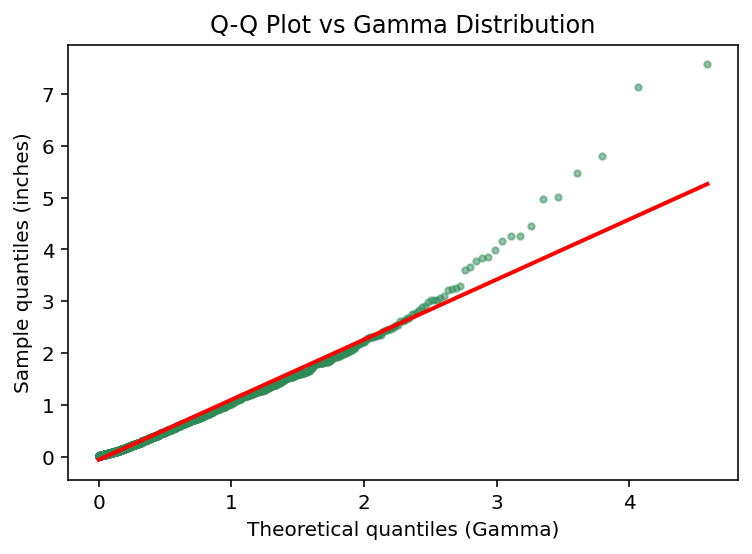

In [88]:
(osm, osr), (slope, intercept, r) = stats.probplot(
    wet, dist=stats.gamma, sparams=(shape, loc, scale), plot=None
)
plt.scatter(osm, osr, s=10, color='seagreen', alpha=0.5, label='Data')
plt.plot(osm, slope*osm + intercept, 'r-', lw=2, label=f'Fit line ($r^2$={r**2:.3f})')
plt.xlabel('Theoretical quantiles (Gamma)')
plt.ylabel('Sample quantiles (inches)')
plt.title('Q-Q Plot vs Gamma Distribution')

Text(0.5, 1.0, 'Q-Q Plot vs Gamma Distribution')

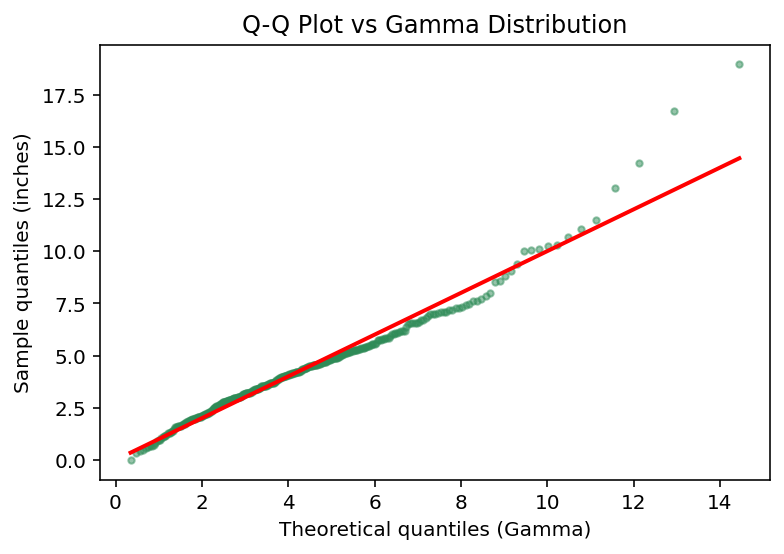

In [90]:
# --- Aggregate to monthly total precipitation ---
monthly = df.set_index('DATE')['PRCP'].resample('MS').sum()
monthly = monthly[monthly.index < monthly.index.max()]  # drop possibly incomplete last month

# --- Fit Gamma distribution ---
shape, loc, scale = stats.gamma.fit(monthly.values, floc=0)

# -- QQ plots
(osm, osr), (slope, intercept, r) = stats.probplot(
    monthly, dist=stats.gamma, sparams=(shape, loc, scale), plot=None
)
# -- plot
plt.scatter(osm, osr, s=10, color='seagreen', alpha=0.5, label='Data')
plt.plot(osm, slope*osm + intercept, 'r-', lw=2, label=f'Fit line ($r^2$={r**2:.3f})')
plt.xlabel('Theoretical quantiles (Gamma)')
plt.ylabel('Sample quantiles (inches)')
plt.title('Q-Q Plot vs Gamma Distribution')

- let's try the probability of exceedance

2.3588920878043496


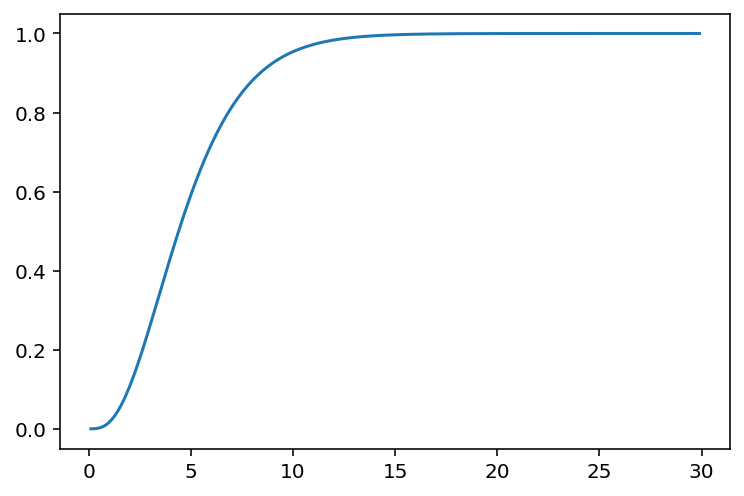

In [111]:
july = monthly[monthly.index.month == 7].sort_values()
val_2026 = july[july.index.year == 2026].values[0]

# --- Fit Gamma distribution ---
shape, loc, scale = stats.gamma.fit(july.values, floc=0)

# --- Fitted (gamma) exceedance probability ---
fit_p = 1 - stats.gamma.cdf(val_2026, shape, loc, scale)
fit_return_period = 1 / fit_p
print (fit_return_period)

x_july = np.arange(0.1,30,0.1)
plt.plot(x_july, stats.gamma.cdf(x_july, shape, loc, scale))


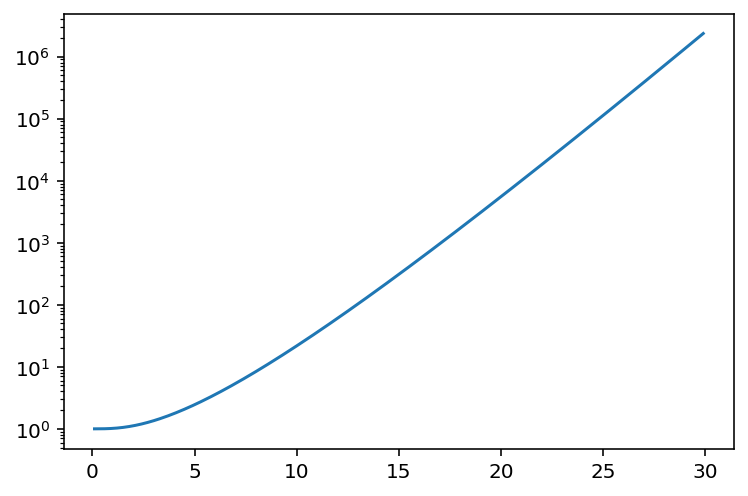

In [110]:
plt.plot(x_july, 1/(1-stats.gamma.cdf(x_july, shape, loc, scale)))
plt.yscale('log')